[2026-07-21 10:48:01] [info     ] 计算因子 v11，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-21 10:48:01] [info     ] ============================================================
[2026-07-21 10:48:01] [info     ] 开始构建训练集 v11                    train_end='2024-12-31 23:59:59' train_start='2022-01-01 00:00:00'
[2026-07-21 10:48:01] [info     ] ============================================================
[2026-07-21 10:48:01] [info     ] build_features 开始              end='2024-12-31 23:59:59' start='2022-01-01 00:00:00'
[2026-07-21 10:48:08] [info     ] 财务特征查询完成（公告日稀疏表）               elapsed=6.71 rows=39274
[2026-07-21 10:48:08] [info     ] 开始分批处理量价数据
[2026-07-21 10:48:08] [info     ] 将处理 6 个半年数据块
[2026-07-21 10:48:08] [info     ] 处理数据块 1/6: 2022-01-01 00:00:00 ~ 2022-06-30 23:59:59
[2026-07-21 10:49:12] [info     ] 数据块 1 完成: 235191 行, 耗时 63.66s
[2026-07-21 10:49:12] [info     ] 处理数据块 2/6: 2022-07-01 00:00:00 ~ 2022-12-31 23:59:59
[2026-07-21 10:50:17] [info     ] 数据块 2 完成: 262505 

时段,IC
2024-01-15~2024-02-08,0.0473
2024-09-24~2024-10-08,0.0421

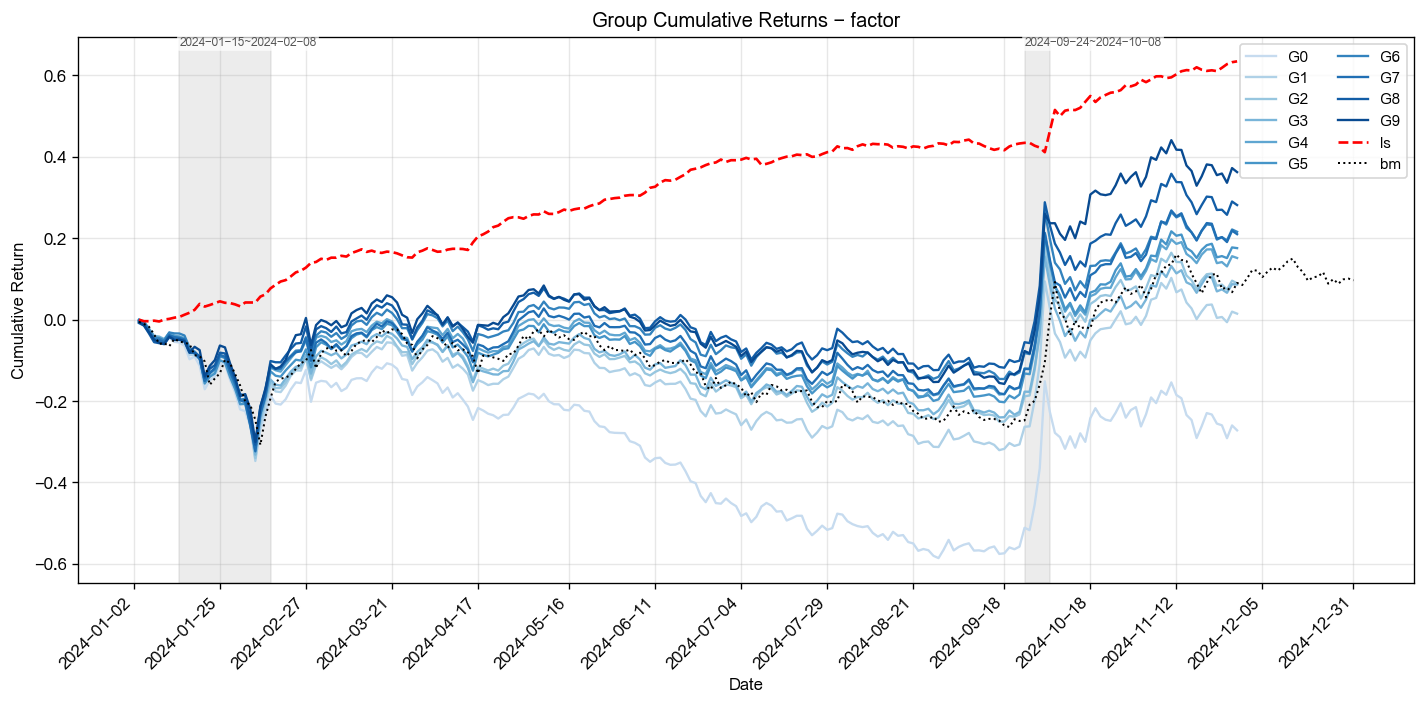
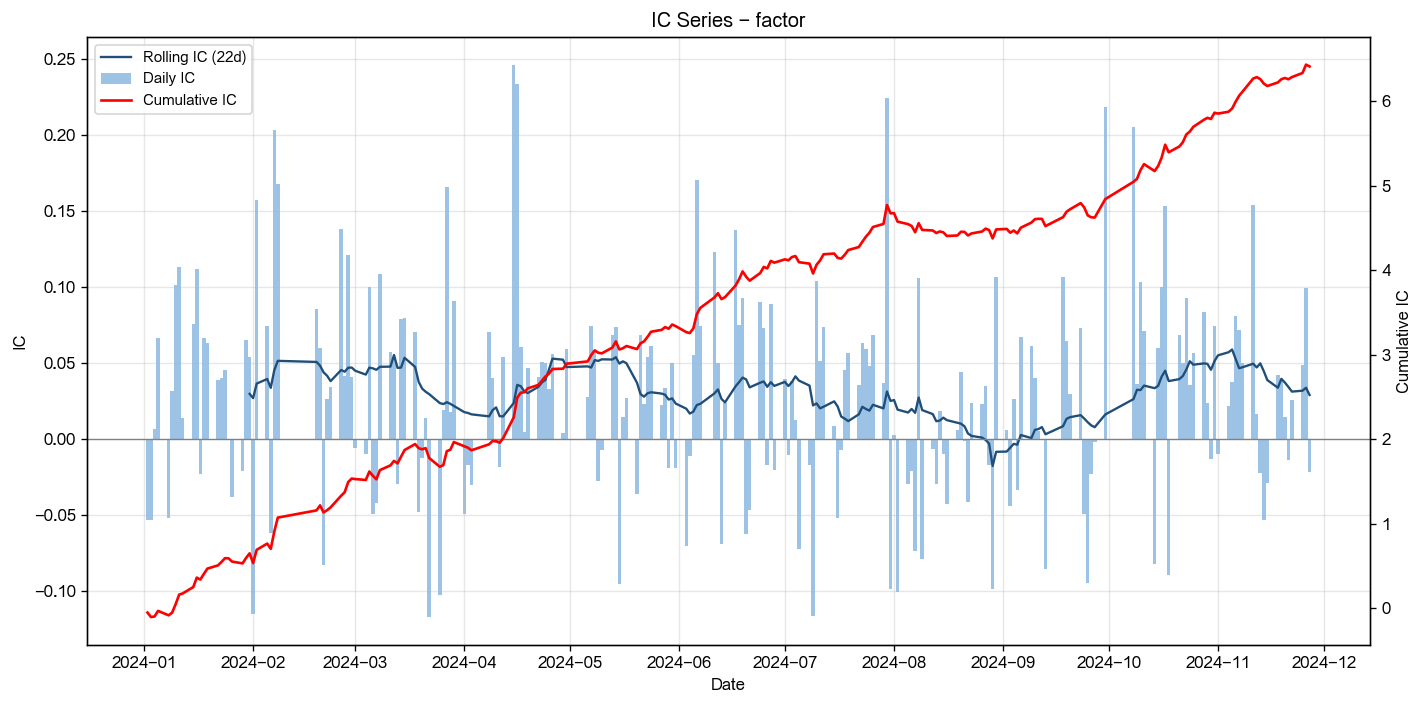
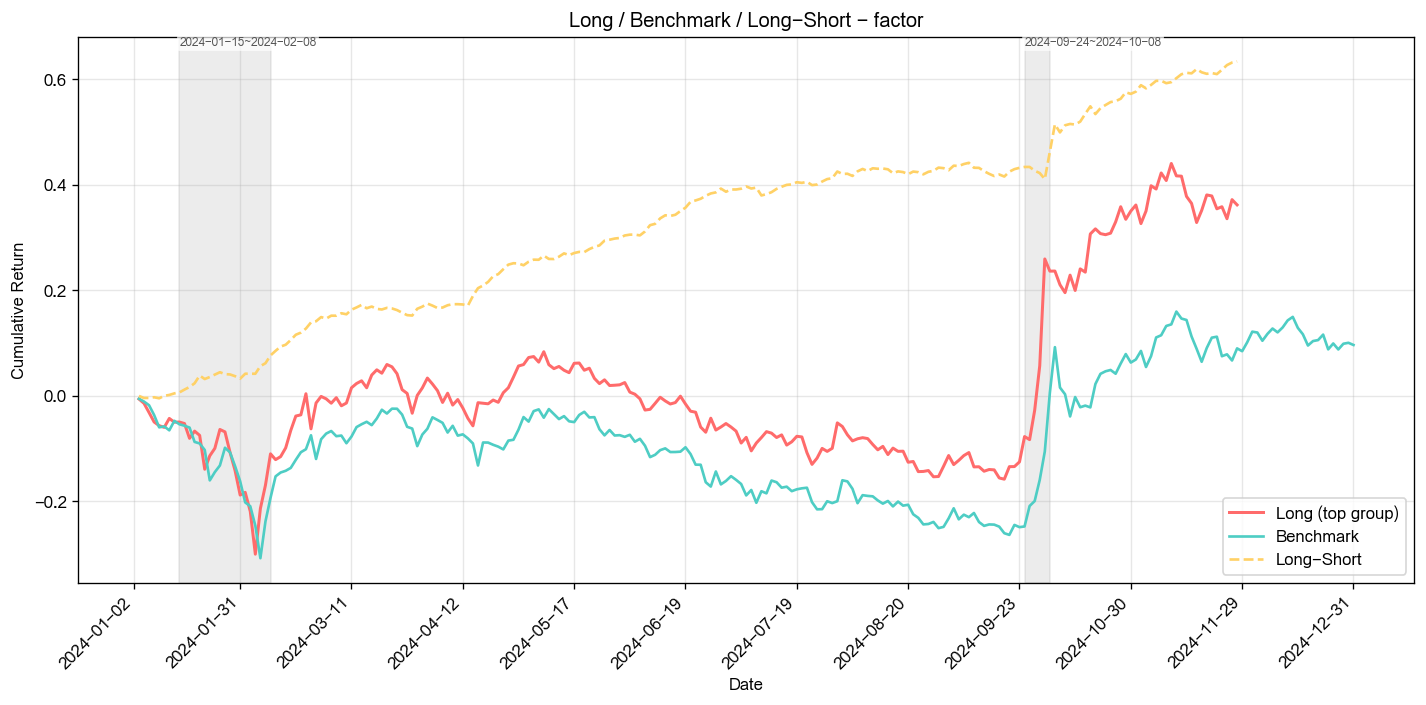
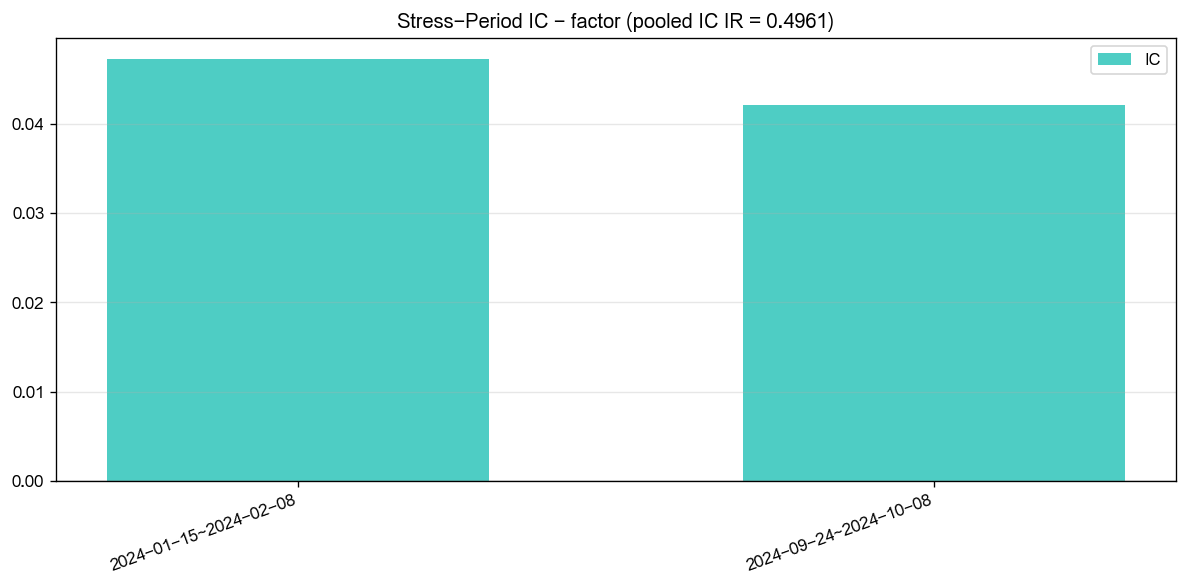
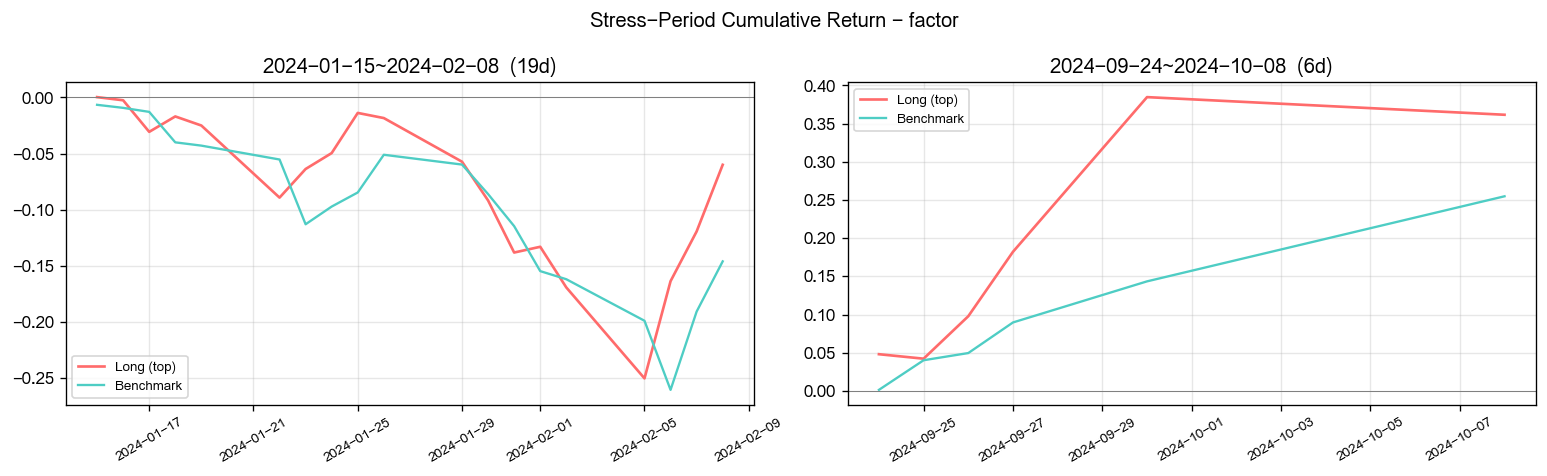

[2026-07-21 11:20:40] [info     ] ========== 因子池回归 ==========
[2026-07-21 11:20:40] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-21 11:20:41] [info     ] 获取收益率数据, 耗时: 0.7697 秒
[2026-07-21 11:20:41] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.3139 秒
[2026-07-21 11:20:41] [info     ] 统计 回归结果, 耗时: 0.1026 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.5380,0.0657,0.0259,1.0000
2,rsi_12,1.8866,0.0436,0.0231,1.0000
3,cci_14,1.7763,0.0355,0.0200,1.0000
4,amount,1.5104,0.0127,0.0084,0.9000
5,pb,1.4878,0.0098,0.0066,0.9000
6,net_profit_rate_ttm,1.4700,0.0038,0.0026,0.8000
7,gross_profit_rate_ttm,1.4577,0.0067,0.0046,1.0000
8,netflow_amount_main,1.4484,0.0253,0.0174,1.0000
9,netflow_amount_rate_main,1.3475,0.0099,0.0073,1.0000
10,net_active_buy_amount_main,1.3436,0.0161,0.0120,1.0000

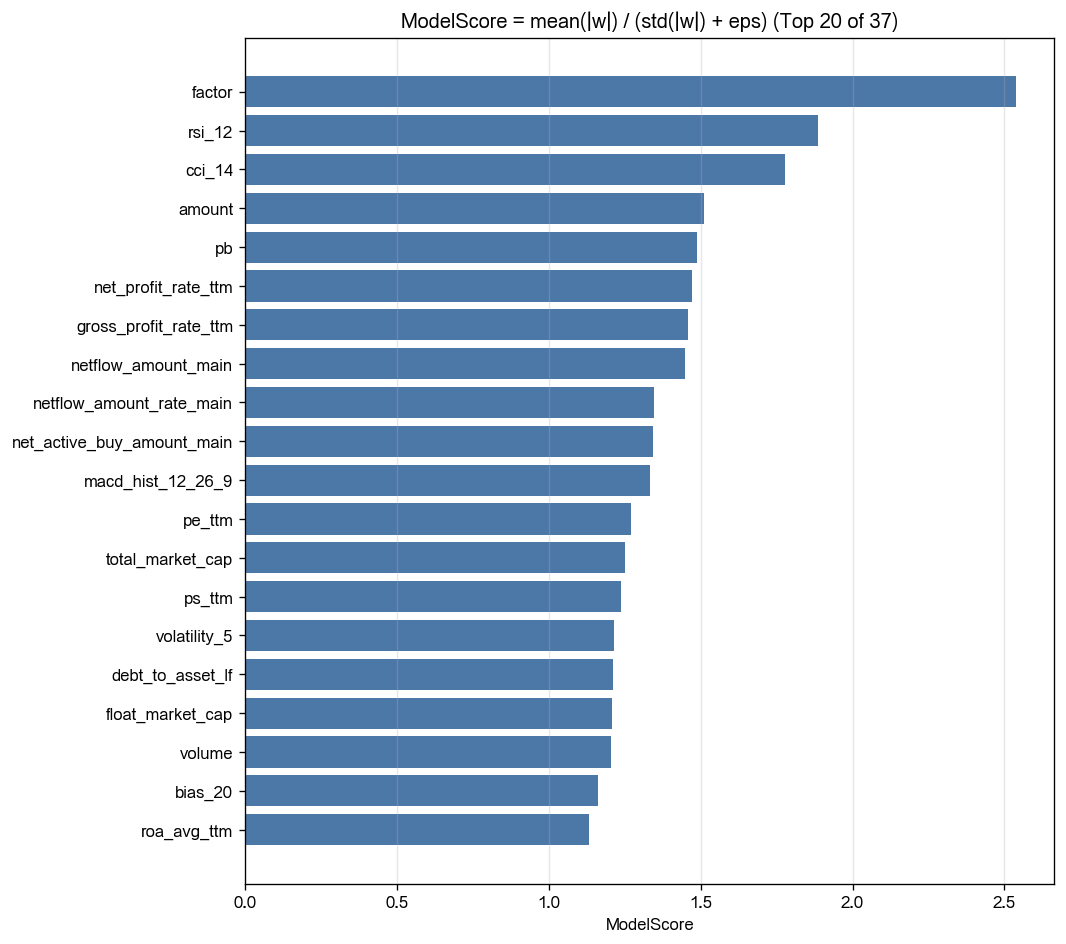
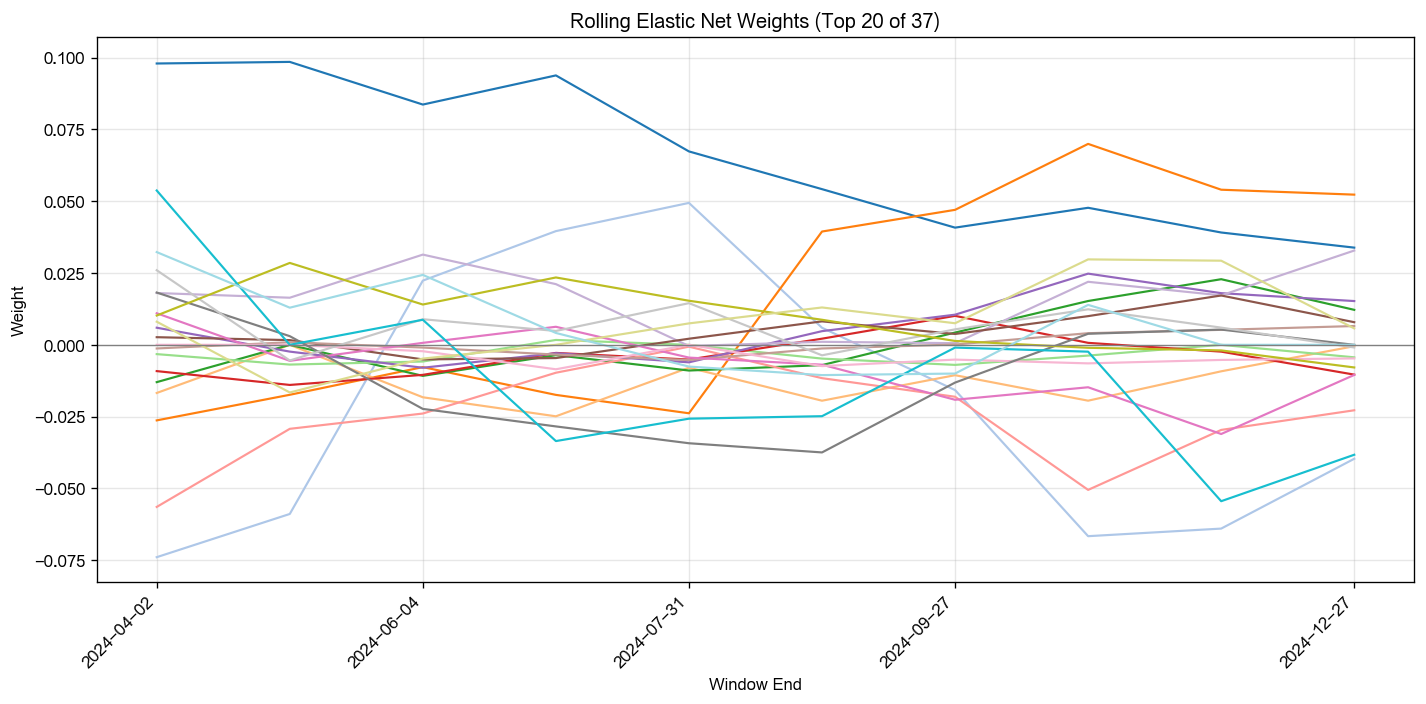
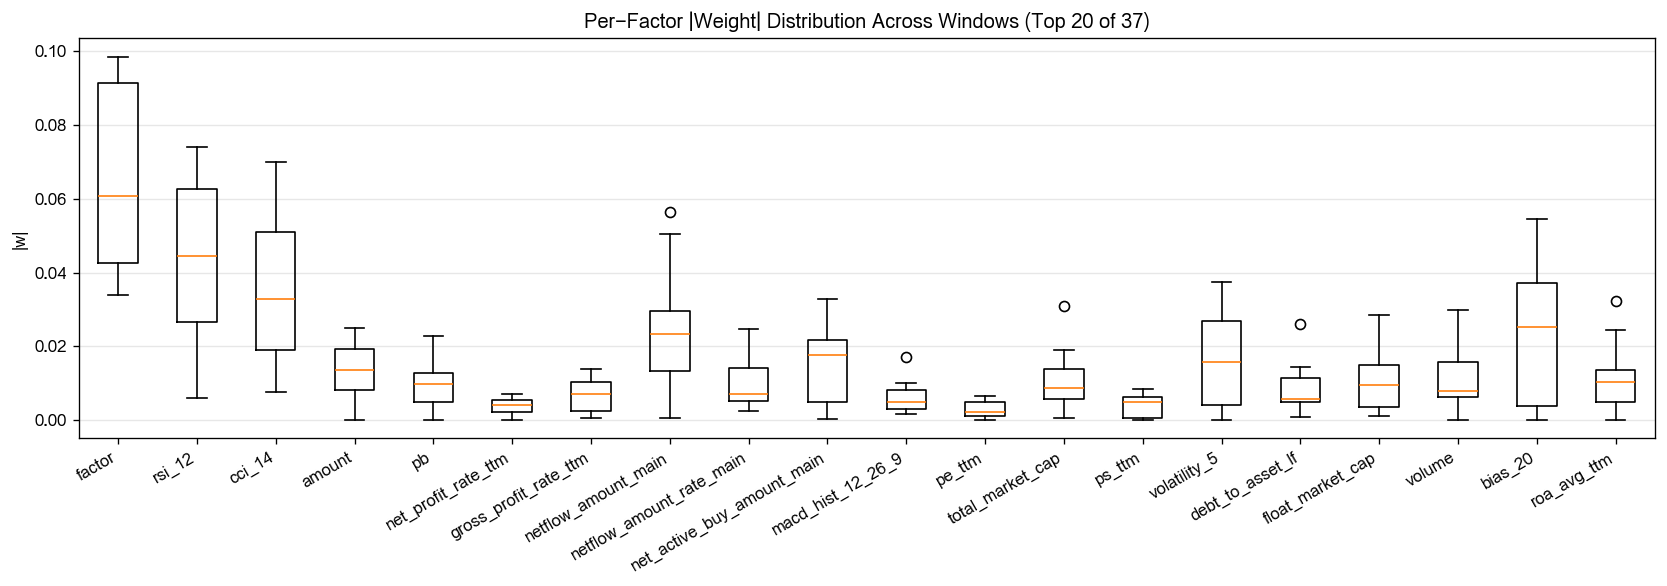
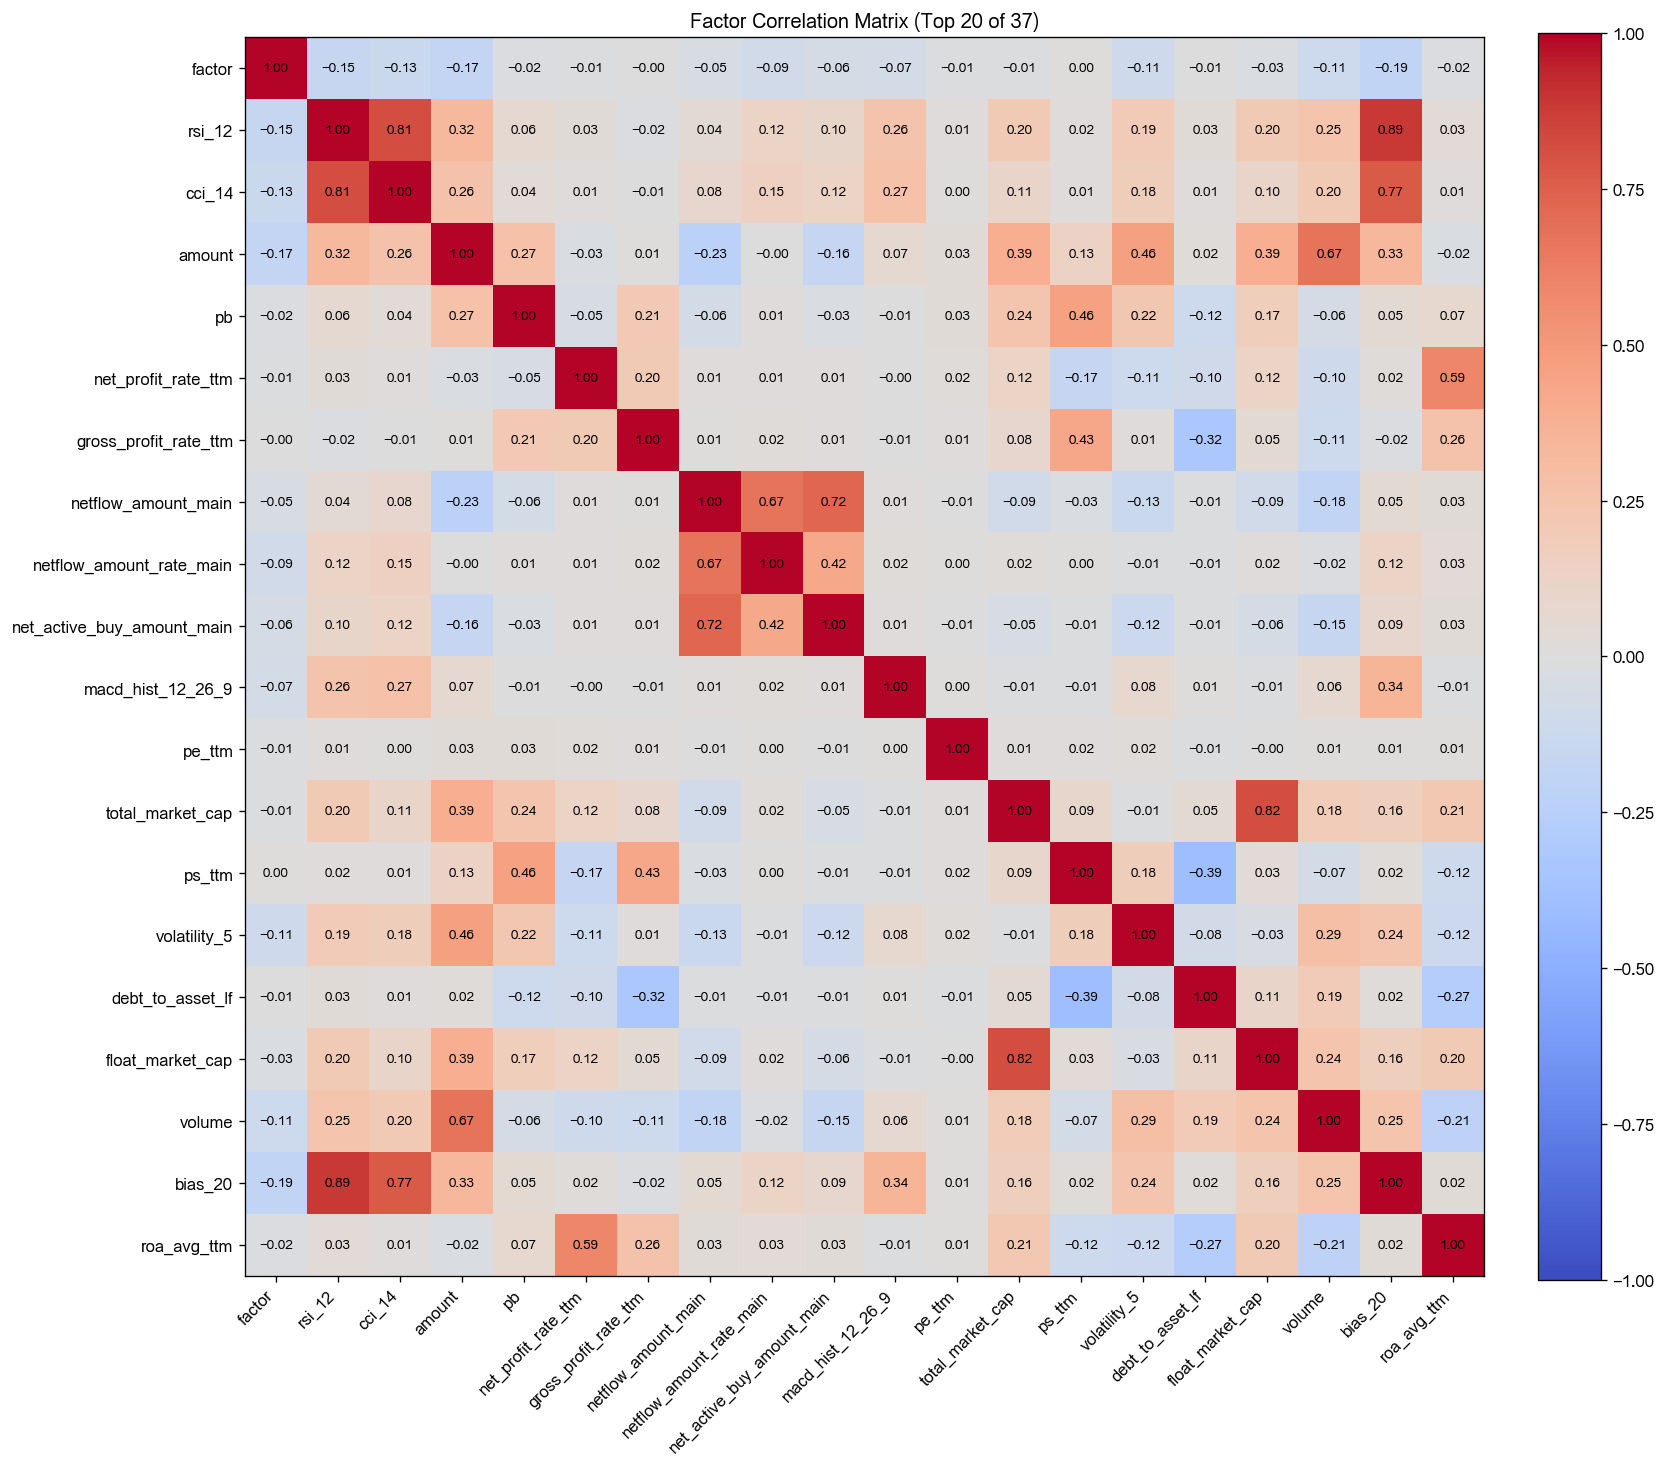

[2026-07-21 11:20:44] [warning  ] 返回的Outputs实例(size=35229163) 大于 64K, 将不会被缓存
[2026-07-21 11:20:44] [info     ] bigalpha_eval.v4 运行完成 [24.240s].


In [1]:
# %%
def main(datasources, start_date, end_date):
    """
    因子：多源融合 XGBoost 机器学习因子 (Multi-Source Fusion ML Factor) v11

    [AI 赛道——AI技术应用关键环节]

    核心理念：
        融合三大信息源构建特征体系，通过 XGBoost 学习特征到未来收益的非线性映射：
        1.  量价 + 日内微观结构特征（来自 bar1m 分钟K线，SQL 窗口函数计算）
        2.  财务质量特征（来自 financial 报表数据，公告日 PIT + 前向填充）
        3.  市场状态特征（截面聚合，帮助模型感知行情冷热——震荡/恐慌/亢奋）
        4.  BARRA 风格因子暴露 + 行业哑变量（来自 exposure 表，可选）
        5.  🆕 订单簿微观结构（来自 bar1m 的 5 档买卖盘口，全新 alpha 维度）

    v7 新增：跨日时序连接因子
        - prev_return / overnight_return / intraday_return

    v8 新增（第一批）：5 类新因子 [#10 #16 #2 #13 #25]
        - #10 已实现半方差分解 / #16 动量期限结构 / #2 开盘尾盘收益不对称
        - #13 Amihud 非流动性 / #25 特征显式交互项

    v9 新增（第二批）：6 类新因子 [#1 #3 #4 #6 #8 #11 #22 #23 #26] + 订单簿维度
        【SQL 层 —— 日内微观结构深化】
        - #1  日内收益偏度 (intraday_skew)：分钟收益三阶矩，捕捉买卖压力不对称
        - #3  日内最大回撤 (intraday_max_dd)：1 - low/high，度量日内恐慌程度
        - #4  价格路径效率比 (path_efficiency)：|close-open|/path_length，趋势清晰度
        - path_length 正式启用为特征（v8 已计算但未输出）
        【SQL 层 —— 订单簿微观结构 [全新 alpha 维度]】
        - #6  加权盘口不平衡度 (orderbook_imbalance)：5 档买卖量加权不对称度
        - #8  有效价差 (effective_spread)：买卖一档价差/中间价，度量流动性
        【Pandas 层 —— 衍生特征】
        - #11 波动率期限结构 (vol_term_structure)：vol_5/vol_20 - 1
        - #22 连续涨跌天数 (consecutive_streak)：带方向的连续涨跌计数
        - #23 缺口强度 (gap_intensity)：overnight_return / 滚动标准差
        - #26 时序差分特征 (delta_ret_5, delta_volume_z)：特征变化速度
        【Pandas 层 —— 新增交互项】
        - ob_imbalance_x_volz：盘口不平衡 × 市场波动状态
        - skew_x_breadth：收益偏度 × 市场宽度

    关键设计（防止数据泄漏）：
        - 训练区间写死在代码内（2022-01 ~ 2023-12），评测时平台传入的 start_date/end_date
          仅用于【样本外预测】，绝不参与训练
        - 财务数据使用公告日（date）+ 前向填充至自然日，确保 PIT（Point-In-Time）
        - 时序特征通过 SQL 窗口函数在前 180 天缓冲区内计算，缓冲数据不进入目标区间
        - 市场状态特征在每日截面内独立计算（使用当日所有个股），不跨期
        - 订单簿特征在每日截面内独立聚合，不跨日
        - 标签统一为「次日收益率」，预测值即为因子值（因子方向：值越大越好）

    特殊行情处理 [动荡市态——核心创新]：
        - 市场状态特征 + 样本加权训练（动荡期样本权重 = 1.0 + 0.5 × vol_z）

    特征列表（共 ~75 个特征）：
        [量价类 ~30 个] ret_1/5/20/60, vol_5/20, range_1, volume_z/amount_z,
                      volume_trend, close_position, vwap_deviation, signed_vol_ratio,
                      prev_return, overnight_return, intraday_return,
                      up_semi_vol_5, down_semi_vol_5, open_session_ret, close_session_ret,
                      amihud_5, amihud_20,
                      🆕 intraday_skew, path_efficiency, intraday_max_dd, path_length
        [订单簿类 🆕 2 个] orderbook_imbalance, effective_spread
        [衍生特征 ~12 个] mom_term_1_5/5_20/20_60, ret1_x_volz/volz_x_breadth/
                          roe_x_drawdown/closepos_x_volz,
                          🆕 vol_term_structure, delta_ret_5, delta_volume_z,
                          consecutive_streak, gap_intensity,
                          ob_imbalance_x_volz, skew_x_breadth
        [市场状态 4 个] market_vol_z, market_dispersion, market_breadth, market_drawdown
        [财务类 8 个]  operating_revenue, net_profit_to_parent_shareholders,
                      total_assets, total_equity_to_parent_shareholders,
                      roe, asset_turnover, leverage, profit_margin
        [风格暴露类 10 个] SIZE, BETA, MOMENTUM, RESVOL, SIZENL, BTOP,
                           LIQUIDTY, EARNYILD, GROWTH, LEVERAGE
        [行业哑变量 ~31 个] 申万一级行业 one-hot（可选）

    XGBoost 模型训练 [AI 赛道——模型训练关键环节]
        - 使用 XGBoost Regressor，目标为次日收益率
        - v9：更多特征 → 适度加深加树 + 更强正则化
        - hist 直方图算法加速训练，早停机制防止过拟合

    评测时平台自动替换 datasources / start_date / end_date 三个入参并调用本函数
    """
    import gc
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 训练区间：写死且严格早于 2024 验证/回测区间，避免训练样本穿越。
    # ============================================================
    TRAIN_START = '2022-01-01 00:00:00'
    TRAIN_END   = '2023-12-31 23:59:59'
    LOOKBACK_DAYS = 180  # 缓冲区日历天数

    # ============================================================
    # 特征列表定义
    # ============================================================
    # —— 量价特征（SQL 内计算，来自 bar1m）——
    PRICE_FEATURES = [
        # 原有量价特征 [v7]
        'ret_1', 'ret_5', 'ret_20', 'ret_60',             # 多期限收益
        'vol_5', 'vol_20',                               # 波动率
        'range_1',                                       # 日内振幅
        'volume_z', 'amount_z',                          # 量能异常
        'close_position',                                # 收盘位置
        'vwap_deviation',                                # VWAP偏离
        'signed_vol_ratio',                              # 主动买卖比
        'prev_return',                                   # 跨日连接
        'overnight_return',                              # 隔夜跳空
        'intraday_return',                               # 日内方向
        # v8 新增 SQL 层特征
        'up_semi_vol_5',                                 # 上行半方差 [#10]
        'down_semi_vol_5',                               # 下行半方差 [#10]
        'open_session_ret',                              # 开盘30分钟收益 [#2]
        'close_session_ret',                             # 尾盘30分钟收益 [#2]
        # v9 新增 SQL 层特征 —— 日内微观结构深化
        'intraday_skew',                                 # 日内收益偏度 [#1]
        'path_efficiency',                               # 价格路径效率比 [#4]
        'intraday_max_dd',                               # 日内最大回撤 [#3]
        'path_length',                                   # 价格路径总长度 [v8已有,v9启用]
        # v9 新增 SQL 层特征 —— 订单簿微观结构 [全新alpha维度]
        'orderbook_imbalance',                           # 加权盘口不平衡度 [#6]
        'effective_spread',                              # 有效价差 [#8]
    ]

    # —— v8：动量期限结构特征（pandas 层计算）——
    MOM_TERM_STRUCTURE = [
        'mom_term_1_5',                                  # ret_1 - ret_5 [#16]
        'mom_term_5_20',                                 # ret_5 - ret_20 [#16]
    ]

    # —— v8：特征显式交互项（pandas 层计算）——
    INTERACTION_FEATURES = [
        'ret1_x_volz',                                   # ret_1 × market_vol_z [#25]
        'volz_x_breadth'                                # volume_z × market_breadth [#25]
    ]

    # —— v9 新增：pandas 层衍生特征 ——
    V9_DERIVED_FEATURES = [
        'vol_term_structure',                            # 波动率期限结构 [#11]
        'delta_ret_5',                                   # 动量时序差分 [#26]
        'delta_volume_z',                                # 量能时序差分 [#26]
        'gap_intensity',                                 # 缺口强度 [#23]
        'consecutive_streak',                            # 连续涨跌天数 [#22]
        'ob_imbalance_x_volz',                           # 盘口不平衡 x 波动状态
        'skew_x_breadth',                                # 日内偏度 x 市场宽度
    ]

    # —— 市场状态特征 ——
    MARKET_REGIME_FEATURES = [
        'market_vol_z', 'market_dispersion',
        'market_breadth', 'market_drawdown',
    ]

    FIN_RAW_COLS = [
        'operating_revenue',
        'net_profit_to_parent_shareholders',
        'total_assets',
        'total_equity_to_parent_shareholders',
    ]
    FINANCIAL_MOMENTUM_FEATURES = [
        # 季度环比变化
        'roe_qoq', 'roe_growth', 
        'profit_margin_qoq', 'profit_margin_growth',
        'asset_turnover_qoq', 'asset_turnover_growth',
        'leverage_change',
        
        # 年同比变化
        'roe_yoy', 'profit_margin_yoy', 'asset_turnover_yoy', 'leverage_yoy',
        
        # 加速度（变化的变化）
        'roe_accel', 'profit_margin_accel',
        
        # 相对历史均值的偏离
        'roe_vs_ma4', 'roe_vs_ma4_z',
        'profit_margin_vs_ma4', 'profit_margin_vs_ma4_z',
        'asset_turnover_vs_ma4',
        
        # 连续改善次数 (total improvements in window)
        'roe_improve_count', 'profit_margin_improve_count',
        
        # 🆕 连续改善连胜 (consecutive streak)
        'roe_streak', 'profit_margin_streak',
    ]


    # 全部特征
    ALL_PRICE_FIN_FEATURES = (
        PRICE_FEATURES + FINANCIAL_MOMENTUM_FEATURES + MARKET_REGIME_FEATURES
        + MOM_TERM_STRUCTURE + INTERACTION_FEATURES + V9_DERIVED_FEATURES
    )

    # ============================================================
    # 特征工程函数：从 bar1m + financial 构建特征矩阵
    # ============================================================
    def build_features(financial_table, bar1m_table, sd, ed, need_label=False):
        """
        构建特征矩阵 - 按半年分批处理以节省内存
        """
        import gc
        
        t0 = time.time()
        logger.info("build_features 开始", start=str(sd), end=str(ed))

        start_date = pd.to_datetime(sd)
        end_date = pd.to_datetime(ed)
        
        # ============================================================
        # 第 1 步：先获取财务数据（一次性，但内存占用小）
        # ============================================================
        t_fin = time.time()
        fin_start = start_date - pd.Timedelta(days=730)
        
        fin_select = ', '.join(FIN_RAW_COLS)
        fin_sql = f"""
        SELECT date, instrument, {fin_select}
        FROM {financial_table}
        WHERE category='lf' AND shift=0
        """
        fin = dai.query(fin_sql, filters={'date': [fin_start, ed]}).df()
        
        if not fin.empty:
            # Arrow/DuckDB 可能分别返回 datetime64[us] 和 datetime64[ns]；
            # merge_asof 要求时间键的单位也完全一致。
            fin['date'] = pd.to_datetime(fin['date']).astype('datetime64[ns]')
            # dai 的不同查询可能分别返回 object/category；Pandas 合并键必须同类型。
            fin['instrument'] = fin['instrument'].astype(str)
            # 同一证券同一公告日可能存在重复版本；保留查询结果中的最后一条。
            fin = (fin.sort_values(['instrument', 'date'])
                   .drop_duplicates(['instrument', 'date'], keep='last')
                   .reset_index(drop=True))

            # 先在稀疏的公告日序列上计算财务变化，再用 merge_asof 做 PIT 合并。
            # 不能先扩展为自然日，否则 diff(4) 会变成 4 天差而不是约 4 个报告期差。
            # 也不能 bfill，因为那会把尚未公告的财务数据填到过去。
            # 计算财务比率
            fin['roe'] = fin['net_profit_to_parent_shareholders'] / fin['total_equity_to_parent_shareholders'].replace(0, np.nan)
            fin['asset_turnover'] = fin['operating_revenue'] / fin['total_assets'].replace(0, np.nan)
            fin['leverage'] = fin['total_assets'] / fin['total_equity_to_parent_shareholders'].replace(0, np.nan)
            fin['profit_margin'] = fin['net_profit_to_parent_shareholders'] / fin['operating_revenue'].replace(0, np.nan)
            
            # 计算财务动量特征（在完整财务数据上计算）
            fin = fin.sort_values(['instrument', 'date'])
            # ============================================================
            # 财务动量特征：比较当前与历史值
            # ============================================================

            # 1. 季度环比变化 (Quarter-over-Quarter)
            for metric in ['roe', 'profit_margin', 'asset_turnover']:
                fin[f'{metric}_qoq'] = fin.groupby('instrument')[metric].diff(1)
                fin[f'{metric}_growth'] = fin.groupby('instrument')[metric].pct_change(1)
                fin[f'{metric}_yoy'] = fin.groupby('instrument')[metric].diff(4)

            # 2. 杠杆的变化
            fin['leverage_change'] = fin.groupby('instrument')['leverage'].diff(1)
            fin['leverage_yoy'] = fin.groupby('instrument')['leverage'].diff(4)

            # 3. 加速度（第二次差分也必须在证券组内完成）
            for metric in ['roe', 'profit_margin']:
                first_diff = fin.groupby('instrument')[metric].diff(1)
                fin[f'{metric}_accel'] = first_diff.groupby(fin['instrument']).diff(1)

            # 4. 相对历史均值的偏离
            for metric in ['roe', 'profit_margin', 'asset_turnover']:
                rolling_mean = fin.groupby('instrument')[metric].transform(
                    lambda x: x.rolling(4, min_periods=2).mean()
                )
                rolling_std = fin.groupby('instrument')[metric].transform(
                    lambda x: x.rolling(4, min_periods=2).std()
                )
                fin[f'{metric}_vs_ma4'] = fin[metric] - rolling_mean
                fin[f'{metric}_vs_ma4_z'] = (fin[metric] - rolling_mean) / rolling_std.replace(0, np.nan)

            # 5. 连续改善计数 (Total Improvements in Window)
            # Using numpy for speed, raw=True for performance
            def calc_improvement_count_numpy(x):
                """
                计算窗口内改善的总次数
                等价于: sum((x - x.shift(1)) > 0)
                x: numpy array, raw=True
                """
                if len(x) < 2:
                    return 0.0
                # x[1:] - x[:-1] 等价于 x.diff() 但不包括第一个元素
                # 注意：需要加上第一个元素对应的位置（没有diff，默认为False）
                diff = x[1:] - x[:-1]
                return float((diff > 0).sum())

            for metric in ['roe', 'profit_margin']:
                fin[f'{metric}_improve_count'] = fin.groupby('instrument')[metric].transform(
                    lambda x: x.rolling(4, min_periods=2).apply(calc_improvement_count_numpy, raw=True)
                )

            # 6. 连续改善连胜 (Consecutive Streak)
            def calc_streak_numpy(x):
                """
                计算最近连续改善的季度数
                等价于: 从最新往前数，直到遇到第一个没有改善的季度
                x: numpy array, raw=True
                """
                if len(x) < 2:
                    return 0.0
                
                # 计算相邻差异
                diff = x[1:] - x[:-1]
                improvements = diff > 0
                
                # 从最新往前数连续改善的个数
                streak = 0
                for i in range(len(improvements) - 1, -1, -1):
                    if improvements[i]:
                        streak += 1
                    else:
                        break
                
                return float(streak)

            for metric in ['roe', 'profit_margin']:
                fin[f'{metric}_streak'] = fin.groupby('instrument')[metric].transform(
                    lambda x: x.rolling(4, min_periods=2).apply(calc_streak_numpy, raw=True)
                )
            # 只保留需要的列
            fin = fin[['date', 'instrument'] + FINANCIAL_MOMENTUM_FEATURES]
            for c in FINANCIAL_MOMENTUM_FEATURES:
                fin[c] = pd.to_numeric(fin[c], errors='coerce').astype('float32')
            
            gc.collect()

            logger.info("财务特征查询完成（公告日稀疏表）",
                        rows=len(fin), elapsed=round(time.time() - t_fin, 2))
        else:
            logger.warning("财务数据查询为空，仅使用量价特征")
            fin = pd.DataFrame()

        # ============================================================
        # 第 2 步：按半年分批处理量价数据
        # ============================================================
        logger.info("开始分批处理量价数据")
        
        # 将时间范围按半年切分
        chunk_months = 6
        all_chunks = []
        
        # chunk 边界表示要输出的日期范围。每个 chunk 查询时单独向前取
        # LOOKBACK_DAYS，避免滚动窗口在半年边界重置并丢失交易日。
        chunk_boundaries = []
        chunk_start = start_date
        while chunk_start <= end_date:
            chunk_end = min(
                chunk_start + pd.DateOffset(months=chunk_months) - pd.Timedelta(seconds=1),
                end_date,
            )
            chunk_boundaries.append((chunk_start, chunk_end))
            chunk_start = chunk_end + pd.Timedelta(seconds=1)
        
        logger.info(f"将处理 {len(chunk_boundaries)} 个半年数据块")
        
        for idx, (chunk_start_dt, chunk_end_dt) in enumerate(chunk_boundaries):
            t_chunk = time.time()
            query_start_dt = chunk_start_dt - pd.Timedelta(days=LOOKBACK_DAYS)
            query_start_str = query_start_dt.strftime('%Y-%m-%d %H:%M:%S')
            chunk_start_str = chunk_start_dt.strftime('%Y-%m-%d %H:%M:%S')
            chunk_end_str = chunk_end_dt.strftime('%Y-%m-%d %H:%M:%S')
            
            logger.info(f"处理数据块 {idx+1}/{len(chunk_boundaries)}: {chunk_start_str} ~ {chunk_end_str}")
            
            # ============================================================
            # 量价 SQL（只查询当前 chunk）
            # ============================================================
            price_sql = f"""
            WITH cte_bars AS (
                SELECT
                    date,
                    instrument,
                    date::DATE AS trading_day,
                    open, high, low, close, volume, amount,
                    lag(volume, 1) OVER (PARTITION BY instrument, date::DATE ORDER BY date) AS prev_cum_volume,
                    lag(amount, 1) OVER (PARTITION BY instrument, date::DATE ORDER BY date) AS prev_cum_amount,
                    lag(close, 1) OVER (PARTITION BY instrument, date::DATE ORDER BY date) AS prev_close,
                    close / NULLIF(lag(close, 1) OVER (PARTITION BY instrument, date::DATE ORDER BY date), 0) - 1 AS minute_ret,
                    ask_price1, bid_price1,
                    ask_volume1, ask_volume2, ask_volume3, ask_volume4, ask_volume5,
                    bid_volume1, bid_volume2, bid_volume3, bid_volume4, bid_volume5
                FROM {bar1m_table}
                WHERE volume > 0 AND close > 0 AND open > 0 AND high > 0 AND low > 0
            ),
            cte_with_ob AS (
                SELECT *,
                    GREATEST(volume - COALESCE(prev_cum_volume, 0), 0) AS minute_volume,
                    GREATEST(amount - COALESCE(prev_cum_amount, 0), 0) AS minute_amount,
                    (COALESCE(ask_volume1, 0) * 1.0 +
                    COALESCE(ask_volume2, 0) * 0.7408 +
                    COALESCE(ask_volume3, 0) * 0.5488 +
                    COALESCE(ask_volume4, 0) * 0.4066 +
                    COALESCE(ask_volume5, 0) * 0.3012) AS weight_ask,
                    (COALESCE(bid_volume1, 0) * 1.0 +
                    COALESCE(bid_volume2, 0) * 0.7408 +
                    COALESCE(bid_volume3, 0) * 0.5488 +
                    COALESCE(bid_volume4, 0) * 0.4066 +
                    COALESCE(bid_volume5, 0) * 0.3012) AS weight_bid
                FROM cte_bars
            ),
            cte_enriched AS (
                SELECT *,
                    (weight_bid - weight_ask) / NULLIF(weight_bid + weight_ask, 0) AS ob_imbalance,
                    (ask_price1 - bid_price1) / NULLIF((ask_price1 + bid_price1) / 2.0, 0) AS eff_spread,
                    minute_ret * minute_ret AS minute_ret_sq,
                    minute_ret * minute_ret * minute_ret AS minute_ret_cu
                FROM cte_with_ob
            ),
            daily_raw AS (
                SELECT
                    CAST(trading_day AS DATETIME) AS date,
                    instrument,
                    arg_min(open, date) AS open,
                    max(high) AS high,
                    min(low) AS low,
                    arg_max(close, date) AS close,
                    arg_max(volume, date)::DOUBLE AS volume,
                    arg_max(amount, date)::DOUBLE AS amount,
                    arg_max(amount, date) / NULLIF(arg_max(volume, date), 0) AS vwap,
                    (arg_max(close, date) - min(low)) / NULLIF(max(high) - min(low), 0) AS close_position,
                    sum(CASE WHEN close > open THEN minute_volume WHEN close < open THEN -minute_volume ELSE 0 END) AS signed_vol,
                    sum(abs(close / NULLIF(prev_close, 0) - 1)) AS path_length,
                    avg(CASE WHEN strftime(date, '%H%M') <= '1000' THEN minute_ret ELSE NULL END) AS open_session_ret,
                    avg(CASE WHEN strftime(date, '%H%M') >= '1430' THEN minute_ret ELSE NULL END) AS close_session_ret,
                    (AVG(minute_ret_cu) - 3 * AVG(minute_ret) * AVG(minute_ret_sq) + 2 * POWER(AVG(minute_ret), 3)) 
                        / POWER(NULLIF(AVG(minute_ret_sq) - POWER(AVG(minute_ret), 2), 0), 1.5) AS intraday_skew,
                    abs(arg_max(close, date) - arg_min(open, date)) / NULLIF(sum(abs(close / NULLIF(prev_close, 0) - 1)), 0) AS path_efficiency,
                    1.0 - min(low) / NULLIF(max(high), 0) AS intraday_max_dd,
                    AVG(ob_imbalance) AS orderbook_imbalance,
                    AVG(eff_spread) AS effective_spread,
                    count(*) AS bar_count
                FROM cte_enriched
                GROUP BY trading_day, instrument
            ),
            daily_with_lag AS (
                SELECT
                    date, instrument,
                    open, high, low, close, volume, amount,
                    vwap, close_position, signed_vol, path_length,
                    open_session_ret, close_session_ret,
                    intraday_skew, path_efficiency, intraday_max_dd,
                    orderbook_imbalance, effective_spread, bar_count,
                    close / NULLIF(lag(close, 1) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS ret_1,
                    close / NULLIF(lag(close, 5) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS ret_5,
                    close / NULLIF(lag(close, 20) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS ret_20,
                    close / NULLIF(lag(close, 60) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS ret_60,
                    (high - low) / NULLIF(close, 0) AS range_1,
                    close / NULLIF(lag(close, 1) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS prev_return,
                    open / NULLIF(lag(close, 1) OVER (PARTITION BY instrument ORDER BY date), 0) - 1 AS overnight_return,
                    close / NULLIF(open, 0) - 1 AS intraday_return,
                    ln(volume + 1) AS log_volume,
                    ln(amount + 1) AS log_amount
                FROM daily_raw
            ),
            daily_features AS (
                SELECT
                    *,
                    nanstd(ret_1) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW) AS vol_5,
                    nanstd(ret_1) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS vol_20,
                    nanstd(CASE WHEN ret_1 > 0 THEN ret_1 ELSE NULL END) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW) AS up_semi_vol_5,
                    nanstd(CASE WHEN ret_1 < 0 THEN ret_1 ELSE NULL END) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW) AS down_semi_vol_5,
                    (log_volume - avg(log_volume) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW)) 
                        / NULLIF(nanstd(log_volume) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW), 0) AS volume_z,
                    (log_amount - avg(log_amount) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW)) 
                        / NULLIF(nanstd(log_amount) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW), 0) AS amount_z,
                    (close - vwap) / NULLIF(vwap, 0) AS vwap_deviation,
                    signed_vol / NULLIF(volume, 0) AS signed_vol_ratio,
                    count(*) OVER (PARTITION BY instrument ORDER BY date ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS rolling_cnt_20
                FROM daily_with_lag
            )
            SELECT
                date, instrument, close,
                ret_1, ret_5, ret_20, ret_60,
                vol_5, vol_20,
                range_1,
                volume_z, amount_z,
                close_position,
                vwap_deviation,
                signed_vol_ratio,
                prev_return, overnight_return, intraday_return,
                up_semi_vol_5, down_semi_vol_5,
                open_session_ret, close_session_ret,
                intraday_skew, path_efficiency, intraday_max_dd, path_length,
                orderbook_imbalance, effective_spread
            FROM daily_features
            WHERE bar_count >= 30 AND rolling_cnt_20 >= 15
            ORDER BY instrument, date
            """
            
            # 执行查询
            price_df = dai.query(
                price_sql,
                filters={'date': [query_start_str, chunk_end_str]},
                compression=True,
            ).df()
            
            if price_df.empty:
                logger.info(f"数据块 {idx+1} 为空，跳过")
                continue
            
            # 类型转换
            price_df['date'] = pd.to_datetime(
                price_df['date']
            ).astype('datetime64[ns]')
            # compression=True 会把字符串列压缩成 category，先恢复为普通字符串。
            price_df['instrument'] = price_df['instrument'].astype(str)
            for col in PRICE_FEATURES + ['close']:
                if col in price_df.columns:
                    price_df[col] = pd.to_numeric(
                        price_df[col], errors='coerce'
                    ).astype('float32')
            
            # 只保留目标日期范围内的数据（丢弃缓冲期数据）
            price_df = price_df[
                (price_df['date'] >= chunk_start_dt)
                & (price_df['date'] <= chunk_end_dt)
            ]
            
            if price_df.empty:
                logger.info(f"数据块 {idx+1} 无目标日期数据，跳过")
                continue
            
            # ============================================================
            # 合并财务数据
            # ============================================================
            if not fin.empty:
                # 公告日 PIT 合并：每个交易日只取该日以前最近一次已公告数据。
                df_chunk = pd.merge_asof(
                    price_df.sort_values(['date', 'instrument']),
                    fin.sort_values(['date', 'instrument']),
                    on='date', by='instrument', direction='backward',
                    allow_exact_matches=True,
                )
            else:
                df_chunk = price_df.copy()
                for c in FINANCIAL_MOMENTUM_FEATURES:
                    df_chunk[c] = np.nan
            
            # 处理 inf/nan
            all_feature_cols = PRICE_FEATURES + FINANCIAL_MOMENTUM_FEATURES
            for col in all_feature_cols:
                if col in df_chunk.columns:
                    df_chunk[col] = df_chunk[col].replace([np.inf, -np.inf], np.nan)
            
            # 添加到列表
            all_chunks.append(df_chunk)

            logger.info(f"数据块 {idx+1} 完成: {len(price_df)} 行, 耗时 {round(time.time() - t_chunk, 2)}s") 

            # 释放内存
            del price_df
            del df_chunk
            gc.collect()
            

        
        # ============================================================
        # 合并所有 chunk
        # ============================================================
        if not all_chunks:
            logger.warning("所有数据块都为空")
            return pd.DataFrame()
        
        logger.info(f"合并 {len(all_chunks)} 个数据块...")
        df = pd.concat(all_chunks, ignore_index=True)
        
        # 释放 chunk 列表
        del all_chunks
        gc.collect()
        
        # 按 instrument, date 排序
        df = df.sort_values(['instrument', 'date']).reset_index(drop=True)

        # 未来收益只允许作为固定历史训练集的监督标签。预测路径不创建
        # lead/shift(-1) 列，确保截断表与完整表在 cutoff 前严格一致。
        if need_label:
            next_close = df.groupby('instrument')['close'].shift(-1)
            df['label'] = (
                next_close / df['close'].replace(0, np.nan) - 1.0
            ).astype('float32')
        
        all_feature_cols = PRICE_FEATURES + FINANCIAL_MOMENTUM_FEATURES
        # 最终清理
        for col in all_feature_cols:
            if col in df.columns:
                df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        
        logger.info("build_features 结束",
                    rows=len(df),
                    total_elapsed=round(time.time() - t0, 2))
        
        return df
    # ============================================================
    # 辅助函数：添加市场状态特征
    # ============================================================
    def add_market_regime_features(df):
        t0 = time.time()
        df = df.sort_values(['date', 'instrument']).reset_index(drop=True)

        dispersion = df.groupby('date')['ret_1'].std().rename('market_dispersion')

        if 'ret_1' in df.columns:
            breadth = df.groupby('date')['ret_1'].apply(
                lambda x: (x > 0).mean()
            ).rename('market_breadth')
        else:
            breadth = pd.Series(name='market_breadth')

        roll_mean = dispersion.rolling(252, min_periods=60).mean()
        roll_std = dispersion.rolling(252, min_periods=60).std()
        vol_z = ((dispersion - roll_mean) / roll_std.replace(0, np.nan)).rename('market_vol_z')
        vol_z = vol_z.replace([np.inf, -np.inf], np.nan)

        if 'close' in df.columns:
            df['_roll_high_60'] = df.groupby('instrument')['close'].transform(
                lambda x: x.rolling(60, min_periods=10).max()
            )
            df['_dd'] = df['close'] / df['_roll_high_60'].replace(0, np.nan) - 1
            drawdown = df.groupby('date')['_dd'].mean().rename('market_drawdown')
            df.drop(columns=['_roll_high_60', '_dd'], inplace=True)
        else:
            drawdown = pd.Series(name='market_drawdown')

        regime_df = pd.DataFrame({
            'market_dispersion': dispersion,
            'market_breadth': breadth,
            'market_vol_z': vol_z,
            'market_drawdown': drawdown,
        }).reset_index()

        df = pd.merge(df, regime_df, how='left', on='date')

        for c in MARKET_REGIME_FEATURES:
            if c in df.columns:
                # 不能用整个测试区间的中位数填充早期值，否则早期因子会
                # 随未来数据是否存在而变化。0 表示中性市场状态。
                df[c] = df[c].fillna(0.0)

        logger.info("市场状态特征添加完成",
                    features=len(MARKET_REGIME_FEATURES),
                    elapsed=round(time.time() - t0, 2))
        return df

    # ============================================================
    # 衍生特征函数（动量期限结构 + 交互项 + v9 新衍生特征）
    # ============================================================
    def add_derived_features(df):
        t0 = time.time()

        # OPTIMIZATION 18: Use vectorized operations without conditionals where possible
        # Initialize all columns with NaN first
        all_derived = MOM_TERM_STRUCTURE + INTERACTION_FEATURES + V9_DERIVED_FEATURES
        for c in all_derived:
            df[c] = np.nan

        # ---- v8 动量期限结构 ----
        if all(c in df.columns for c in ['ret_1', 'ret_5', 'ret_20']):
            df['mom_term_1_5'] = df['ret_1'] - df['ret_5']
            df['mom_term_5_20'] = df['ret_5'] - df['ret_20']

        # ---- v8 交互项 ----
        if 'ret_1' in df.columns and 'market_vol_z' in df.columns:
            df['ret1_x_volz'] = df['ret_1'] * df['market_vol_z']
        
        if 'volume_z' in df.columns and 'market_breadth' in df.columns:
            df['volz_x_breadth'] = df['volume_z'] * df['market_breadth']
        
        if 'vol_5' in df.columns and 'vol_20' in df.columns:
            df['vol_term_structure'] = df['vol_5'] / df['vol_20'].replace(0, np.nan) - 1.0

        # ---- v9 时序差分 ----
        if 'ret_5' in df.columns:
            df['delta_ret_5'] = df.groupby('instrument')['ret_5'].diff(1)
        
        if 'volume_z' in df.columns:
            df['delta_volume_z'] = df.groupby('instrument')['volume_z'].diff(1)

        # ---- v9 缺口强度 ----
        if 'overnight_return' in df.columns:
            roll_std = df.groupby('instrument')['overnight_return'].transform(
                lambda x: x.rolling(20, min_periods=5).std()
            )
            df['gap_intensity'] = abs(df['overnight_return']) / roll_std.replace(0, np.nan)

        # ---- v9 连续涨跌 ----
        if 'ret_1' in df.columns:
            def _compute_streak(series):
                result = pd.Series(0.0, index=series.index)
                cnt = 0
                for i in range(len(series)):
                    val = series.iloc[i]
                    if pd.isna(val):
                        cnt = 0
                        continue
                    if val > 0:
                        cnt = cnt + 1 if cnt > 0 else 1
                    elif val < 0:
                        cnt = cnt - 1 if cnt < 0 else -1
                    else:
                        cnt = 0
                    result.iloc[i] = float(cnt)
                return result

            df['consecutive_streak'] = df.groupby('instrument', group_keys=False)['ret_1'].apply(_compute_streak)

        # ---- 新增交互项 ----
        if 'orderbook_imbalance' in df.columns and 'market_vol_z' in df.columns:
            df['ob_imbalance_x_volz'] = df['orderbook_imbalance'] * df['market_vol_z']
        
        if 'intraday_skew' in df.columns and 'market_breadth' in df.columns:
            df['skew_x_breadth'] = df['intraday_skew'] * df['market_breadth']

        # OPTIMIZATION 19: Vectorized inf replacement
        for c in all_derived:
            if c in df.columns:
                df[c] = df[c].replace([np.inf, -np.inf], np.nan)

        logger.info("衍生特征添加完成",
                    v8_momentum=len(MOM_TERM_STRUCTURE),
                    v8_interactions=4,
                    v9_derived=len(V9_DERIVED_FEATURES),
                    v9_interactions=2,
                    elapsed=round(time.time() - t0, 2))
        return df
    # ============================================================
    # 第 1 步：用【写死的训练区间】构建特征并拟合模型
    # ============================================================
    logger.info("=" * 60)
    logger.info("开始构建训练集 v11",
                train_start=TRAIN_START, train_end=TRAIN_END)
    logger.info("=" * 60)

    train_df = build_features(
        'bigalpha_2026_financial',
        'bigalpha_2026_stock_bar1m',
        TRAIN_START, TRAIN_END, need_label=True,
    )


    if train_df.empty:
        logger.error("训练集为空，无法训练模型")
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])

    train_df['label'] = train_df['label'].replace([np.inf, -np.inf], np.nan)
    train_df = train_df.dropna(subset=['label'])

    # —— 市场状态特征 ——
    train_df = add_market_regime_features(train_df)


    # —— 衍生特征（v8 momentum term structure + v8 interactions + v9 derived + v9 interactions）——
    train_df = add_derived_features(train_df)



    # —— 动荡行情样本加权 ——
    TURBULENCE_ALPHA = 0.5
    if 'market_vol_z' in train_df.columns:
        train_df['_turbulence'] = np.maximum(0, train_df['market_vol_z'].fillna(0.0))
        train_df['sample_weight'] = 1.0 + TURBULENCE_ALPHA * train_df['_turbulence']
        train_df['sample_weight'] = train_df['sample_weight'].clip(1.0, 3.0)
        logger.info("动荡行情样本权重计算完成",
                    mean_weight=round(train_df['sample_weight'].mean(), 3),
                    max_weight=round(train_df['sample_weight'].max(), 3),
                    turbulent_days=int((train_df['_turbulence'] > 1.0).sum()))
        train_df.drop(columns=['_turbulence'], inplace=True)
    else:
        train_df['sample_weight'] = 1.0

    all_features = list(ALL_PRICE_FIN_FEATURES)

    for c in all_features:
        if c not in train_df.columns:
            train_df[c] = np.nan

    # ============================================================
    # XGBoost 模型训练 [AI 赛道——模型训练关键环节]
    #
    # v9 参数调整思路（相比 v8）：
    #   - n_estimators=350：更多树充分学习新增的 ~13 个特征（从 300 提升）
    #   - max_depth=6：适度加深，捕捉订单簿+微观结构的三阶交互（从 5 提升）
    #   - min_child_weight=25：配合更多特征加强正则化（从 20 提升）
    #   - early_stopping_rounds=40：给予更多耐心（从 30 提升）
    #   - 保留动荡行情样本加权机制
    # ============================================================
    t_fit = time.time()

    # build_features 最终按证券排序；先改为按日期排序，保证验证集是真正的
    # 时间尾部样本，而不是代码排序靠后的若干证券。
    train_df = train_df.sort_values(['date', 'instrument']).reset_index(drop=True)
    n_train = len(train_df)
    if n_train < 100:
        logger.error("有效训练样本不足", samples=n_train)
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])
    n_valid = min(max(int(n_train * 0.1), 2000), max(n_train // 3, 1))
    train_split = train_df.iloc[:-n_valid].copy()
    valid_split = train_df.iloc[-n_valid:].copy()
    del train_df
    gc.collect()

    for col in all_features:
        train_split[col] = pd.to_numeric(train_split[col], errors='coerce')
        valid_split[col] = pd.to_numeric(valid_split[col], errors='coerce')

    train_medians = {}
    for col in all_features:
        med = train_split[col].median()
        train_medians[col] = med if not pd.isna(med) else 0.0
        train_split[col] = train_split[col].fillna(train_medians[col])
        valid_split[col] = valid_split[col].fillna(train_medians[col])

    logger.info("开始训练 XGBoost 模型 v11",
                train_samples=len(train_split),
                valid_samples=len(valid_split),
                features=len(all_features))

    model = xgb.XGBRegressor(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.02,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=25,
        reg_lambda=5.0,
        objective='reg:squarederror',
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=40,
    )

    X_train = train_split[all_features].astype('float32')
    y_train = train_split['label'].astype('float32')
    w_train = train_split['sample_weight'].astype('float32')
    X_valid = valid_split[all_features].astype('float32')
    y_valid = valid_split['label'].astype('float32')

    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )

    del X_train, y_train, w_train, X_valid, y_valid, train_split, valid_split
    gc.collect()

    logger.info("模型训练完成",
                elapsed=round(time.time() - t_fit, 2),
                best_iteration=model.get_booster().best_iteration,
                best_score=round(model.get_booster().best_score, 6))

    # 特征重要性日志（Top 20，v9 特征更多）
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]
    top_features = [(all_features[i], round(importances[i], 4)) for i in top_idx]
    logger.info("Top 20 特征重要性", top_features=top_features)

    # ============================================================
    # 第 2 步：用【平台传入的测试区间】做样本外预测
    # ============================================================
    logger.info("=" * 60)
    logger.info("开始构建测试集并预测 v11",
                test_start=start_date, test_end=end_date)
    logger.info("=" * 60)

    bar1m_table = datasources['bar1m']
    # 官方未来函数自检示例只替换 bar1m。未传 financial 时使用固定的
    # 历史财务表；正式评测传入 financial 时仍优先使用平台映射。
    financial_table = datasources.get(
        'financial', 'bigalpha_2026_financial'
    )

    test_df = build_features(
        financial_table, bar1m_table, start_date, end_date,
        need_label=False,
    )

    if test_df.empty:
        logger.error("测试集为空")
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])

    test_df = add_market_regime_features(test_df)
    test_df = add_derived_features(test_df)

    for c in all_features:
        if c not in test_df.columns:
            test_df[c] = np.nan
        test_df[c] = pd.to_numeric(test_df[c], errors='coerce')

    for col in all_features:
        if col not in test_df.columns:
            test_df[col] = np.nan
        fill_val = train_medians.get(col, 0.0)
        test_df[col] = test_df[col].fillna(fill_val)

    # 预测
    X_test = test_df[all_features].astype('float32')
    test_df['factor'] = model.predict(X_test)
    del X_test

    # ============================================================
    # 第 3 步：对齐中证 1000 成分股并输出
    # ============================================================
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(
        stk_pool['date']
    ).astype('datetime64[ns]')
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    test_df['date'] = pd.to_datetime(
        test_df['date']
    ).astype('datetime64[ns]')
    test_df['instrument'] = test_df['instrument'].astype(str)
    result = pd.merge(
        test_df[['date', 'instrument', 'factor']], stk_pool,
        how='inner', on=['date', 'instrument'],
    )

    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan)
    result = (result.dropna(subset=['factor'])
              .drop_duplicates(['date', 'instrument'], keep='last')
              .sort_values(['date', 'instrument'])
              .reset_index(drop=True))

    logger.info("因子构建完成 v11",
                rows=len(result),
                mean=round(result['factor'].mean(), 6),
                std=round(result['factor'].std(), 6))

    return result[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial',
    }

    start_date = '2024-01-01 00:00:00'
    end_date   = '2024-12-31 23:59:59'

    logger.info(f"计算因子 v11，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    if factor_data.empty:
        logger.error("因子计算返回空结果！")
    else:
        logger.info(f"因子数据行数: {len(factor_data)}")
        logger.info(f"因子统计: mean={factor_data['factor'].mean():.6f}, "
                    f"std={factor_data['factor'].std():.6f}, "
                    f"coverage={factor_data['factor'].notna().mean():.2%}")

        logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
        factor_pool = dai.query(
            "SELECT * FROM bigalpha_2026_factorlib",
            filters={'date': [start_date, end_date]},
        ).df()

        result = M.bigalpha_eval._latest(
            factor_data=factor_data,
            factor_pool=factor_pool,
            process_pools=False,
            show=True,
        )
